In [2]:
import pandas as pd
from itables import init_notebook_mode
import polars as pl
import os
import numpy as np
init_notebook_mode(all_interactive=True)
import polars.selectors as cs
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as pn
from scipy.stats import mannwhitneyu


In [1]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

/home/a379i/Scripts/utils/load_gtf_cgc_dresden.py:106: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Extended predisp' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  cgc.loc[cgc["geneID_short"].isin(extended_dresden_dt["geneID_short"]), "Predisposition"] = "Extended predisp"


In [4]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")
sa = sa[sa["Diag"] != "Unstranded_data"]
len(sa)
sa["key"] = sa["pid"] +  "." + sa["nct_pid"].str.split("_").str[1]



In [6]:
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust.parquet"
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust_cnv.parquet"
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "#Uploaded_variation_snv", "IMPACT_snv", "ANNOTATION_control_snv", "Consequence_snv", "promoterAI_snv",
               "Location_indel", "IMPACT_indel", "ANNOTATION_control_indel", "Consequence_indel",
               "padjust_predisp", "padjust_predisp_extended", "CNV"]
py_or_res_all = pd.read_parquet(or_res_path, columns=needed_cols)
# py_or_res_all = py_or_res_all[py_or_res_all["padjust_predisp_extended"].notna()]
py_or_res_all = py_or_res_all[(py_or_res_all["padjust_predisp_extended"] <= 0.05) | (py_or_res_all["padjust"] <= 0.05)]
py_or_res_all = pd.merge(py_or_res_all, sa[["pid", "Diag", "seq_type", "Oncotree Code"]], left_on="sampleID", right_on="pid")
py_or_res_all = pd.merge(py_or_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER"]], on="geneID", how="left")

py_or_res_all = pd.merge(py_or_res_all, gene_annot_dt[["gene_name", "gene_type", "gene_id"]], right_on= "gene_id", left_on="geneID", how="left")


print(len(py_or_res_all))



74654


In [7]:
expression_outlier_num = pd.DataFrame(py_or_res_all["sampleID"].value_counts())
over_expression_outlier_num = pd.DataFrame(py_or_res_all[py_or_res_all["zScore"] <= 0]["sampleID"].value_counts())
under_expression_outlier_num = pd.DataFrame(py_or_res_all[py_or_res_all["zScore"] > 0]["sampleID"].value_counts())
expression_outlier_num["pid"] = list(expression_outlier_num.index)

In [5]:

cnv_germline = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_exploded_filtered.tsv", sep="\t")
cnv_germline = cnv_germline[cnv_germline["Confidence"] == "HIGH"]

cnv = ( pl.scan_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_exploded_filtered.tsv", separator="\t", infer_schema_length=1000000)
        .filter(pl.col("Type").is_in(["CNN", "HDEL", "AMP"]))
        .filter(pl.col("width") >= 10000)
        .collect(engine="streaming")
      ).to_pandas()

cnv = cnv[((cnv["Type"] == "AMP") | (cnv["Type"] == "HDEL")) & (cnv["width"] >= 10000)]


cnv = cnv.merge(gene_annot_dt[["geneID_short", "gene_name"]], left_on="Gene", right_on="gene_name")
cnv_germline = cnv_germline.merge(gene_annot_dt[["geneID_short", "gene_name"]], left_on="Gene", right_on="gene_name")

cnv = cnv.drop_duplicates(subset=["sampleID", "geneID_short"])
cnv_germline = cnv_germline.drop_duplicates(subset=["sampleID", "geneID_short"])

In [8]:
cnv_germline_del = cnv_germline[cnv_germline["Type"] == "DEL"]


In [57]:
df_outliers = expression_outlier_num
genes_to_plot = cnv_germline['Gene'].unique()

min_pval = 100.0
plots = []
for gene in genes_to_plot:
    # 1. Identify groups
    samples_with_cnv = cnv_germline[cnv_germline['Gene'] == gene]['sampleID'].unique()
    
    plot_df = df_outliers.copy()
    plot_df['CNV_Status'] = plot_df['pid'].isin(samples_with_cnv).map({
        True: 'True', 
        False: 'False'
    })

    # 2. Calculate Significance (Mann-Whitney U test)
    group_with = plot_df[plot_df['CNV_Status'] == 'True']['count']
    group_without = plot_df[plot_df['CNV_Status'] == 'False']['count']
    
    if len(group_with) > 0 and len(group_without) > 0:
        # 'greater' means the first group passed is significantly larger than the second
        stat, p_val = mannwhitneyu(group_with, group_without, alternative='greater')
        p_text = f"pValue = {p_val:.2e}" if p_val < 0.001 else f"pValue = {p_val:.4f}"
    else:
        continue
        p_text = "p = N/A"

    if not (p_val <= min_pval or p_val <= 0.0001):
        continue
    # 3. Create the plot
    p = (
        pn.ggplot(plot_df, pn.aes(x='CNV_Status', y='count'))
        # Using a single color (lightgrey) and removing the legend
        + pn.geom_boxplot(fill="lightgrey", outlier_shape=None, alpha=0.7, show_legend=False) 
        + pn.geom_jitter(width=0.2, alpha=0.3, color="black")
        + pn.labs(
            title=f"{p_text}", # P-value added to title
            x=f"Germline DEL CNV in {gene}",
            y="Total Number of Outliers"
        )
        + pn.theme_bw() # Minimal theme for a cleaner look
    )
    if p_val <= 0.0001:
        min_pval = p_val
        plots.append(p)

In [55]:
print(f"Type of p_val: {type(p_val)}")
print(f"Type of min_pval: {type(min_pval)}")

Type of p_val: <class 'numpy.float64'>
Type of min_pval: <class 'float'>


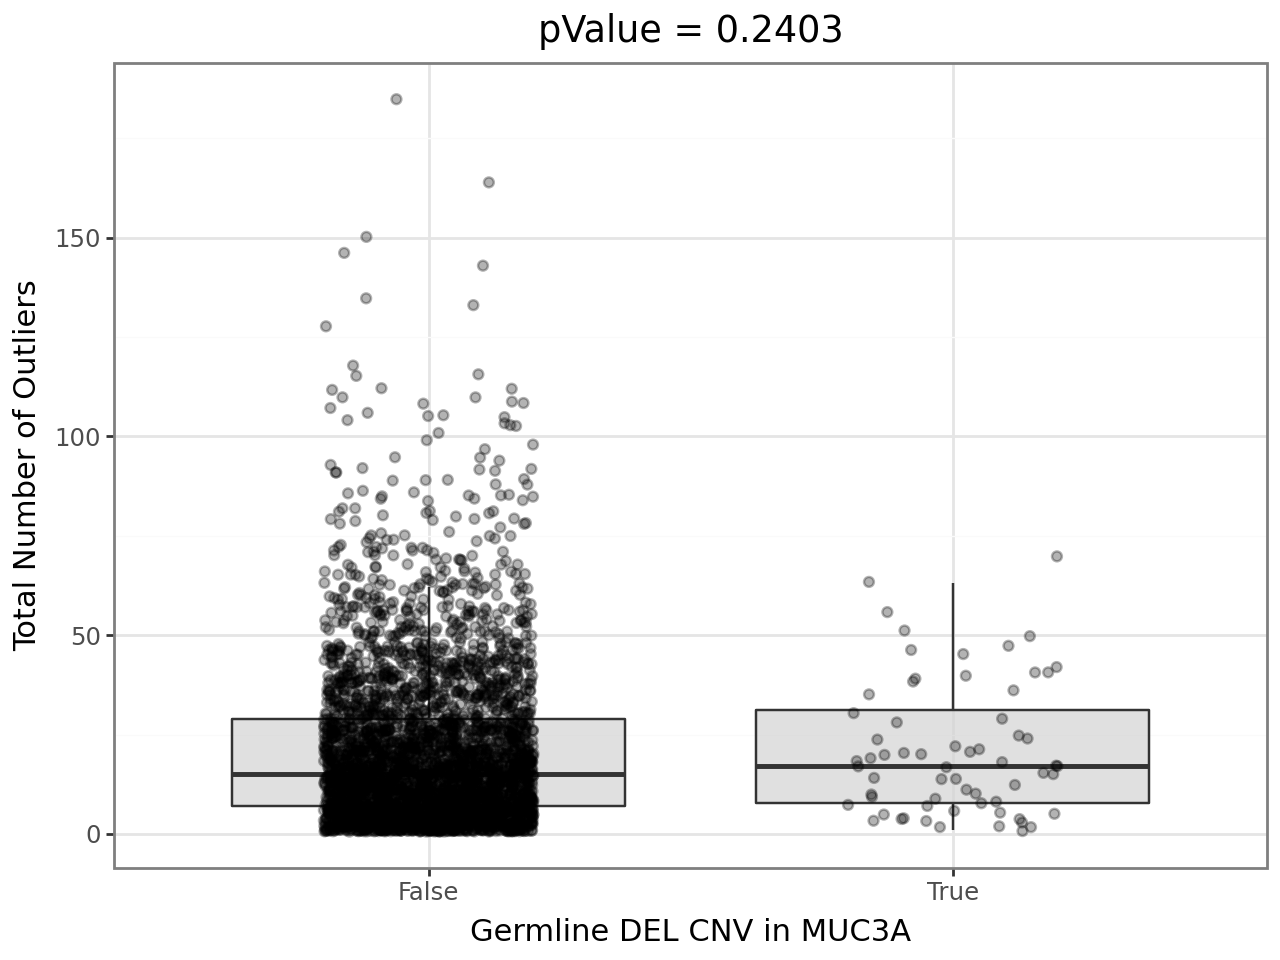

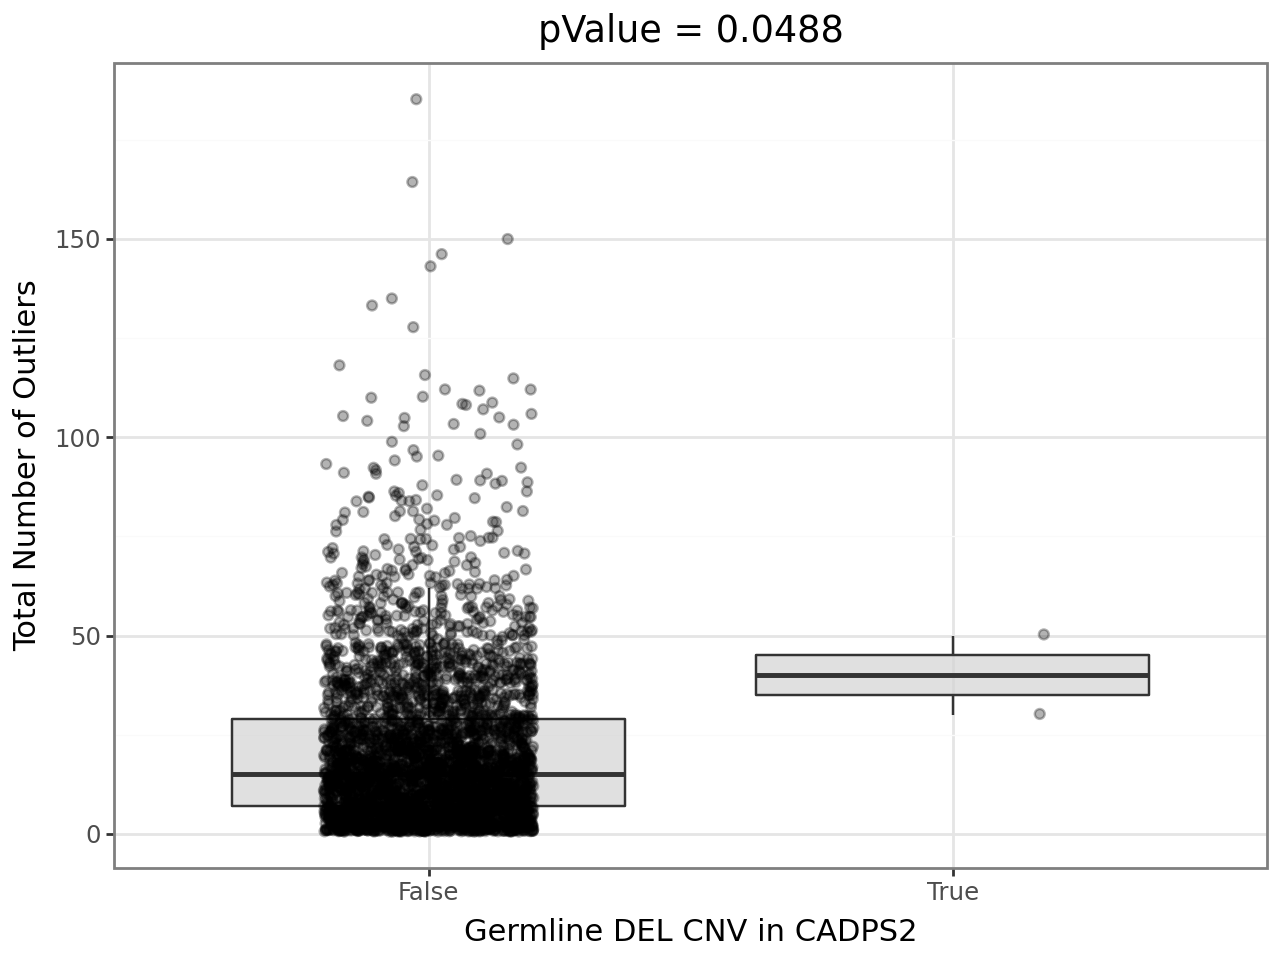

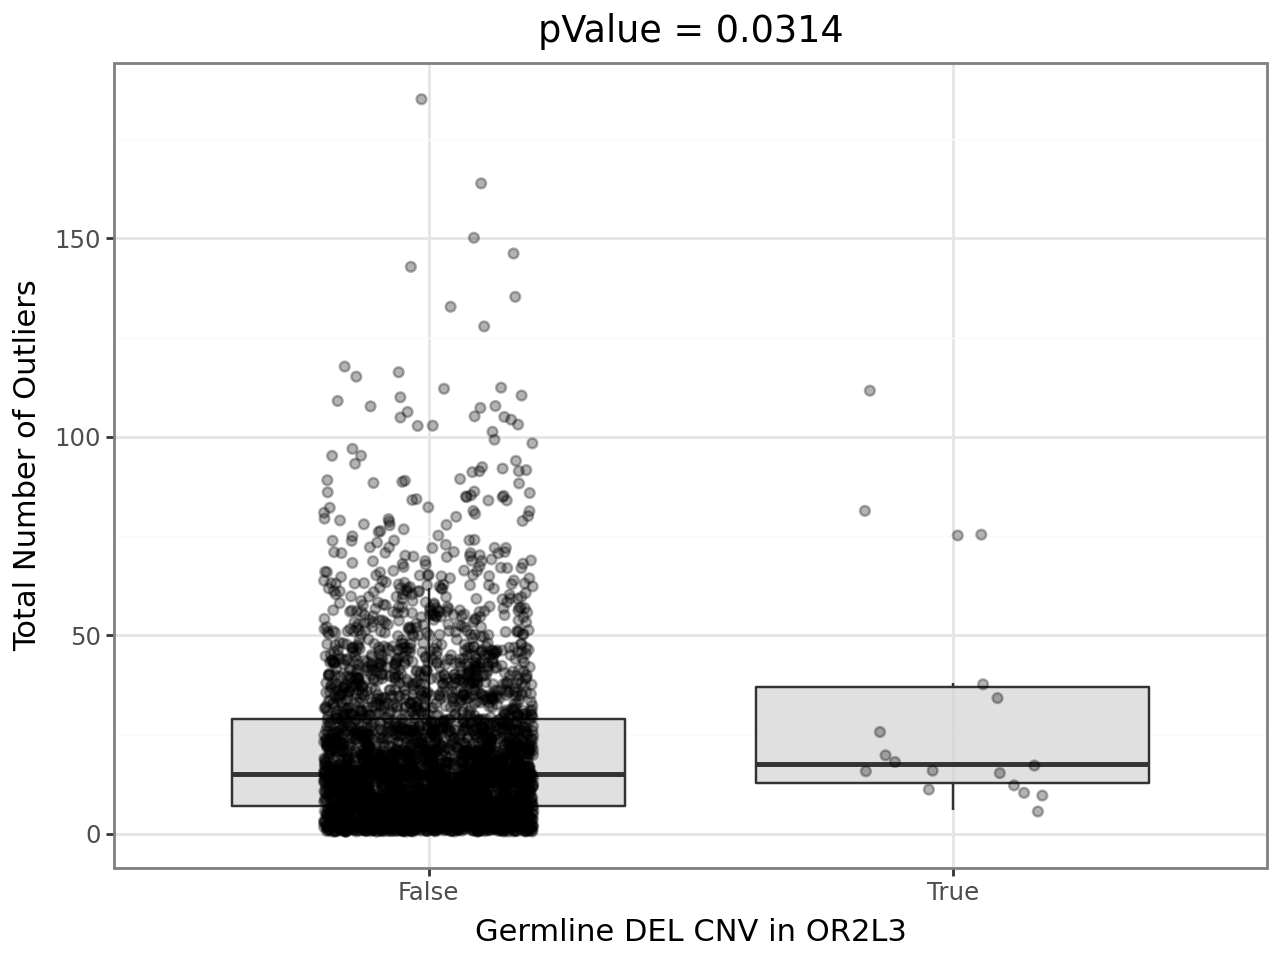

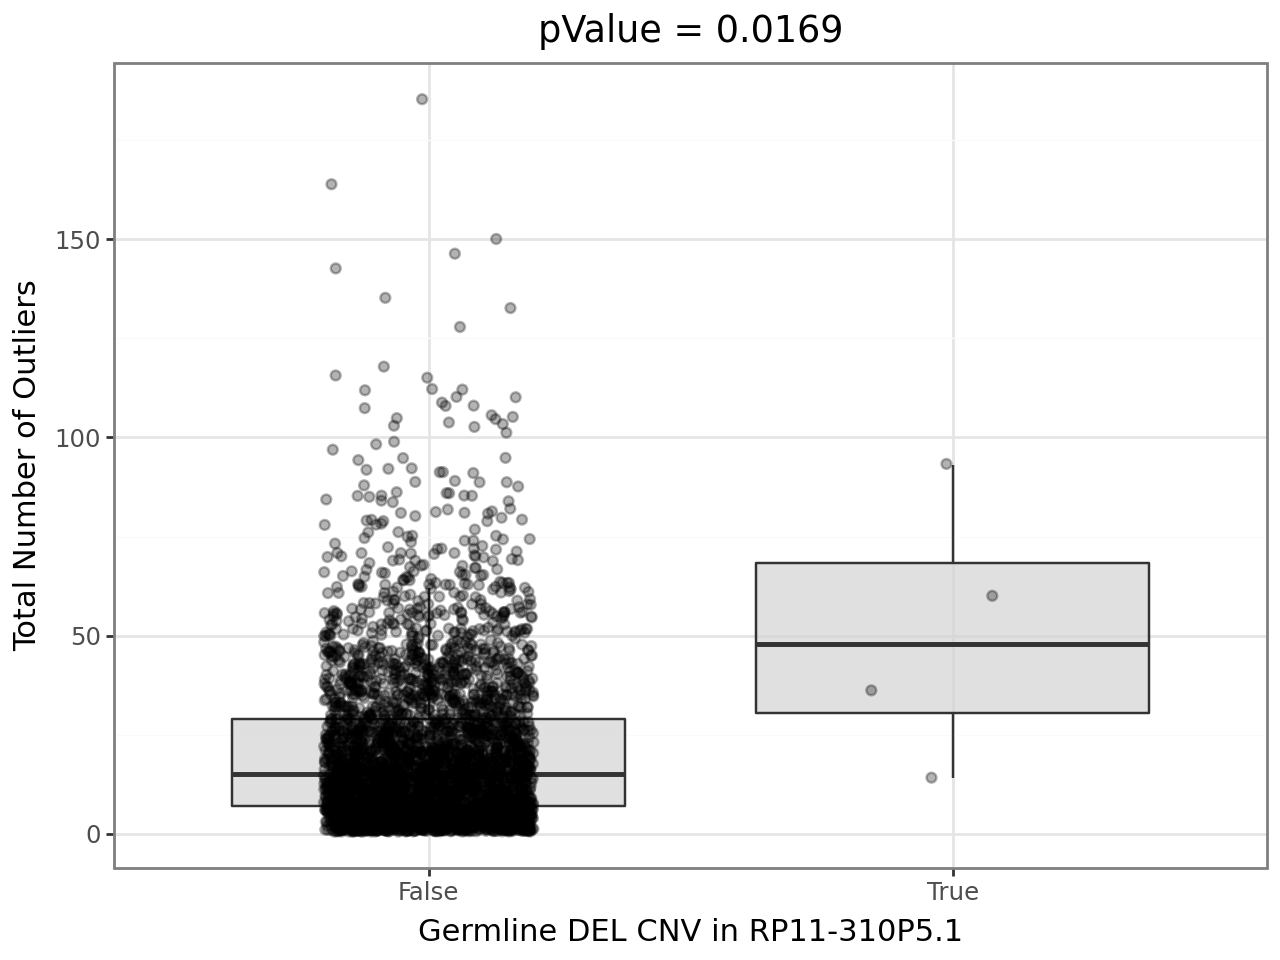

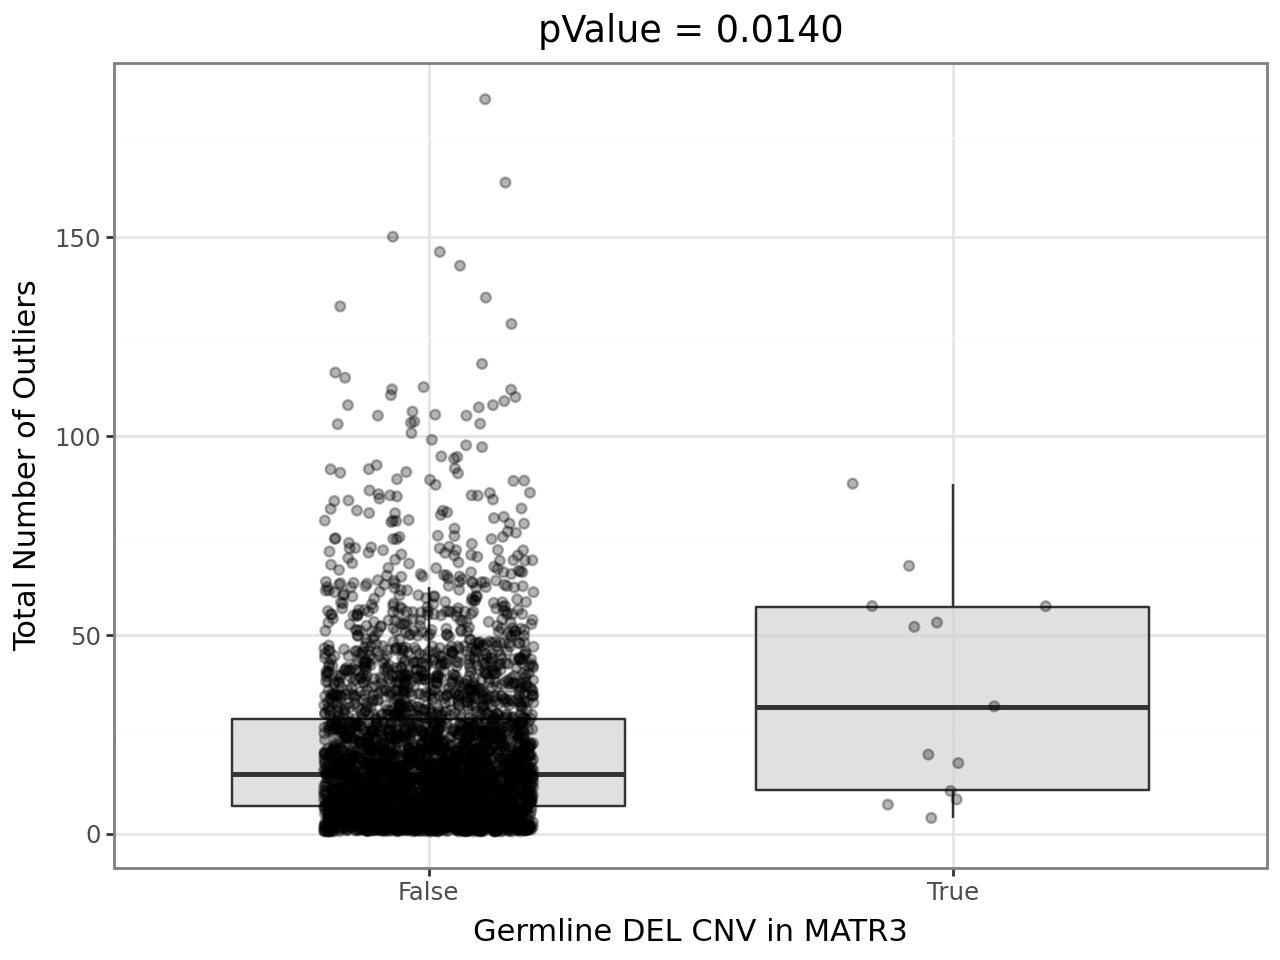

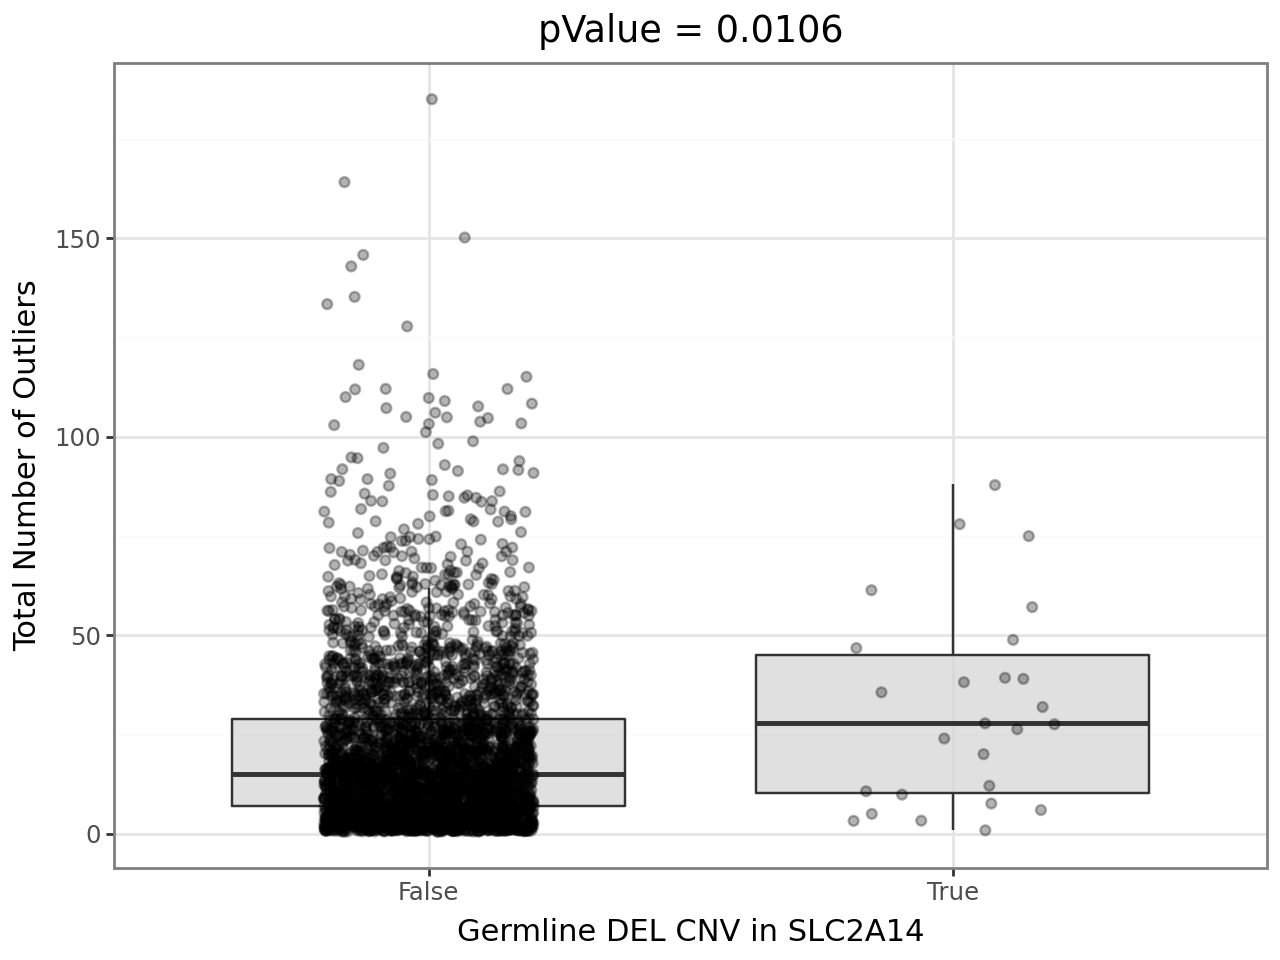

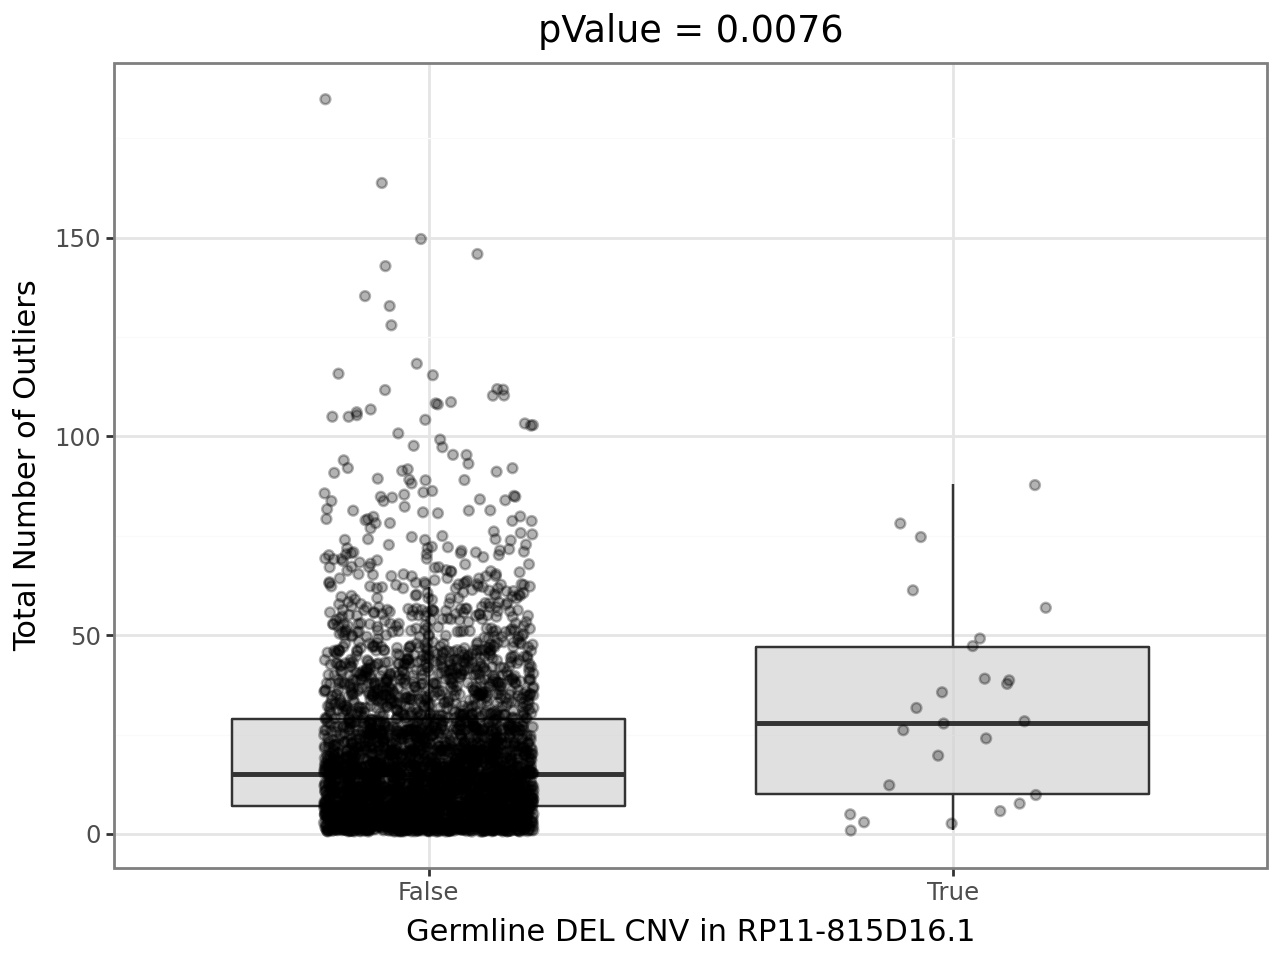

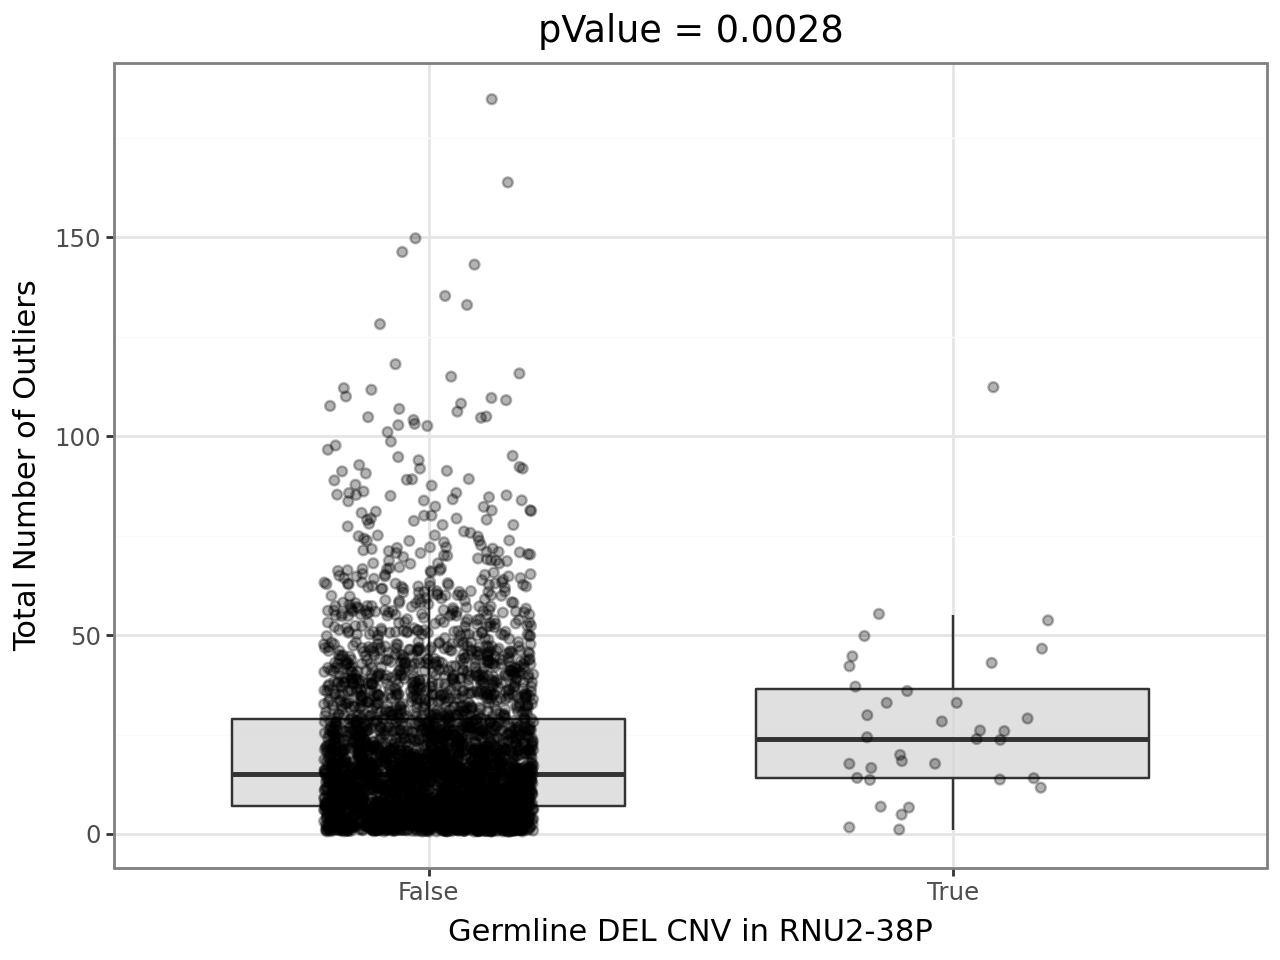

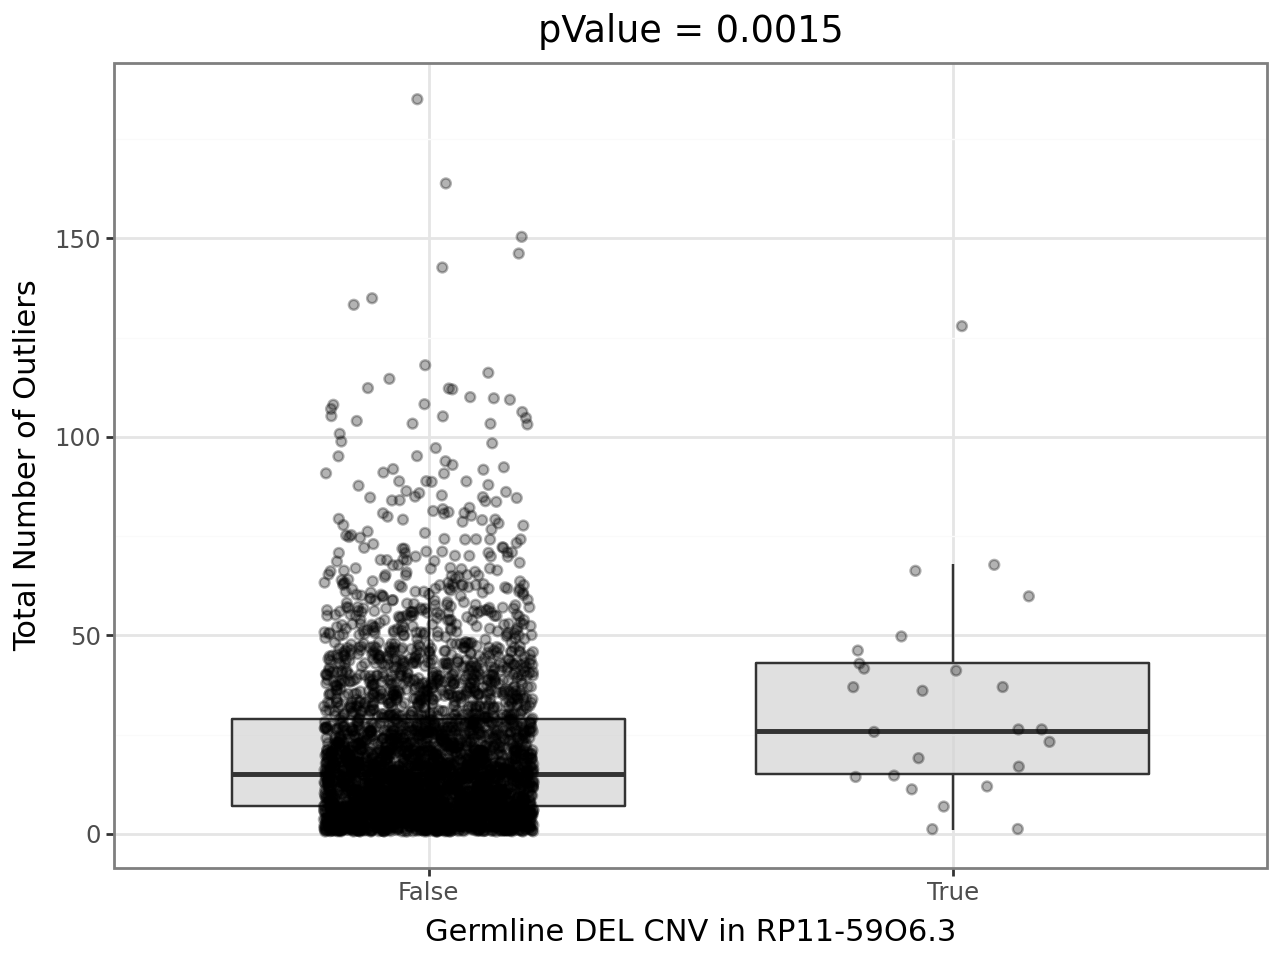

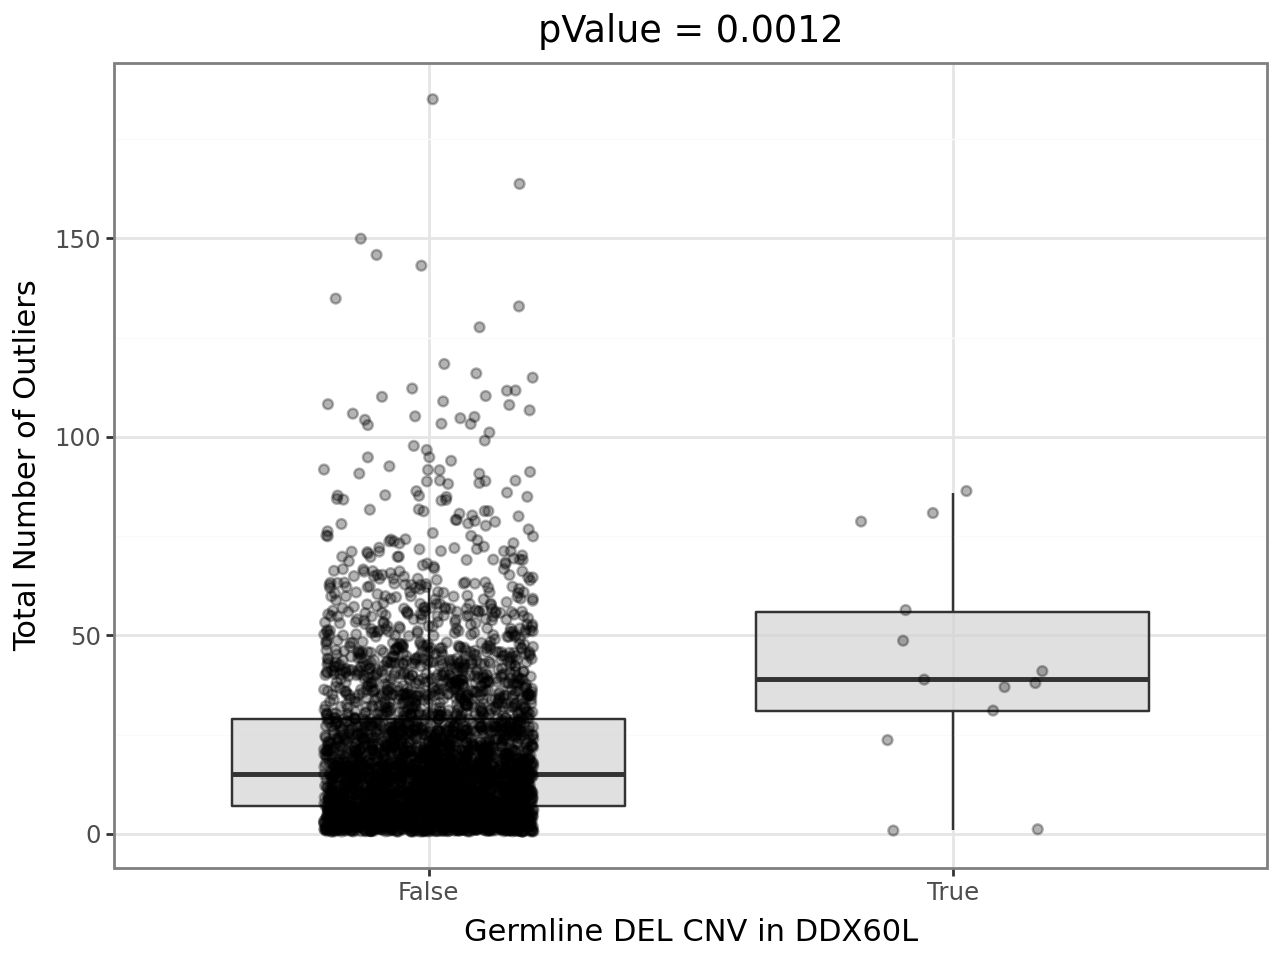

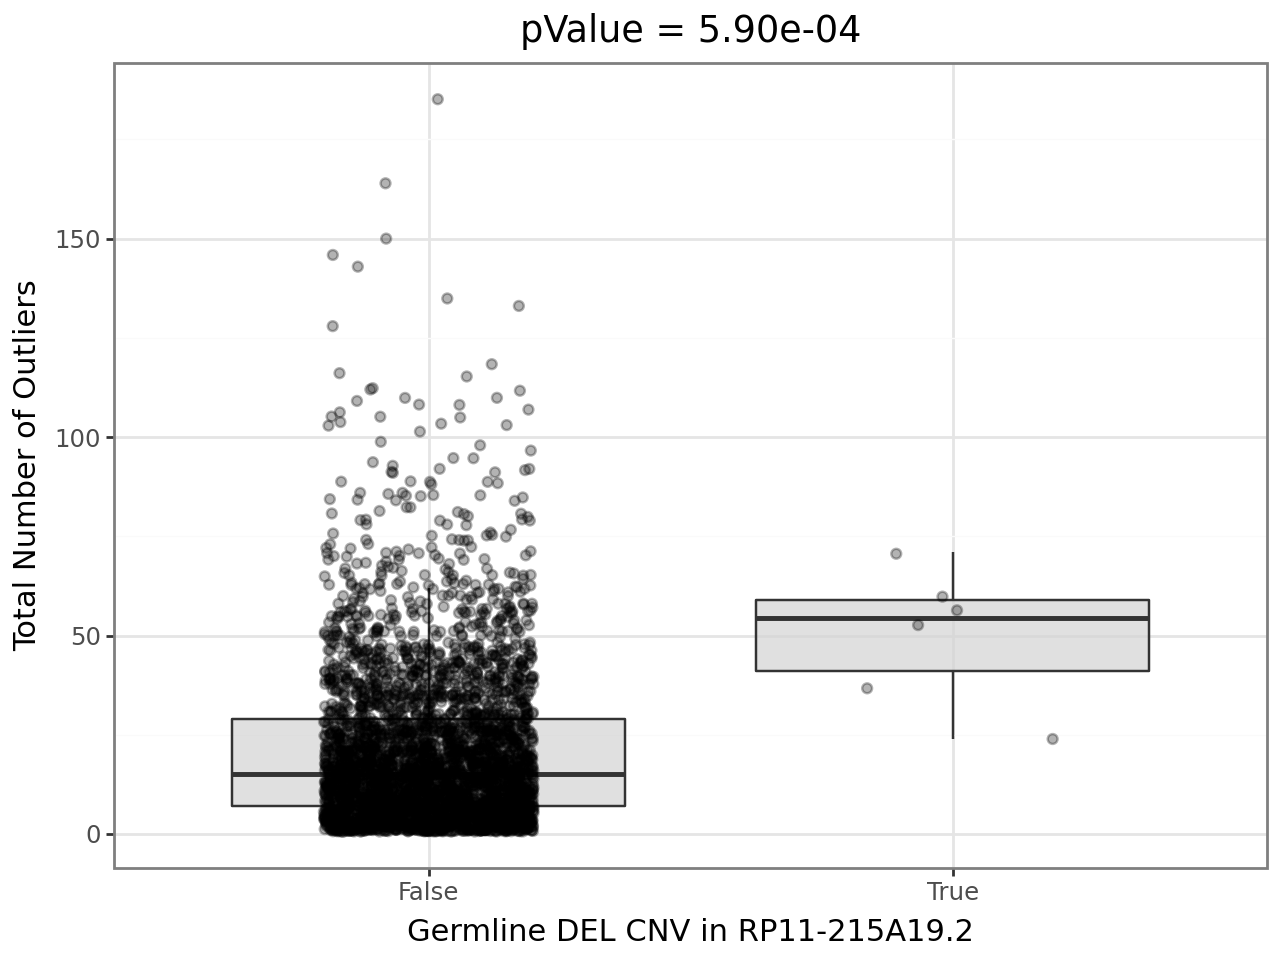

In [59]:
for p in plots:
    p.show()

# Somatic HDEL

In [18]:
df_outliers = expression_outlier_num
genes_to_plot = cnv[cnv["Type"] == "HDEL"]['Gene'].unique()

min_pval = 100.0
plots = []
for gene in genes_to_plot:
    # 1. Identify groups
    samples_with_cnv = cnv[cnv['Gene'] == gene]['sampleID'].unique()
    
    plot_df = df_outliers.copy()
    plot_df['CNV_Status'] = plot_df['pid'].isin(samples_with_cnv).map({
        True: 'True', 
        False: 'False'
    })

    # 2. Calculate Significance (Mann-Whitney U test)
    group_with = plot_df[plot_df['CNV_Status'] == 'True']['count']
    group_without = plot_df[plot_df['CNV_Status'] == 'False']['count']
    
    if len(group_with) > 0 and len(group_without) > 0:
        # 'greater' means the first group passed is significantly larger than the second
        stat, p_val = mannwhitneyu(group_with, group_without, alternative='greater')
        p_text = f"pValue = {p_val:.2e}" if p_val < 0.001 else f"pValue = {p_val:.4f}"
    else:
        continue
        p_text = "p = N/A"

    if not (p_val <= min_pval or p_val <= 0.0001):
        continue
    # 3. Create the plot
    p = (
        pn.ggplot(plot_df, pn.aes(x='CNV_Status', y='count'))
        # Using a single color (lightgrey) and removing the legend
        + pn.geom_boxplot(fill="lightgrey", outlier_shape=None, alpha=0.7, show_legend=False) 
        + pn.geom_jitter(width=0.2, alpha=0.3, color="black")
        + pn.labs(
            title=f"{p_text}", # P-value added to title
            x=f"Somatic HDEL CNV in {gene}",
            y="Total number of gene expression outliers"
        )
        + pn.theme_bw() # Minimal theme for a cleaner look
    )
    if p_val < min_pval:
        min_pval = p_val
    if p_val <= 0.001:
        min_pval = p_val
        plots.append(p)


KeyboardInterrupt


KeyboardInterrupt



ERROR! Session/line number was not unique in database. History logging moved to new session 938


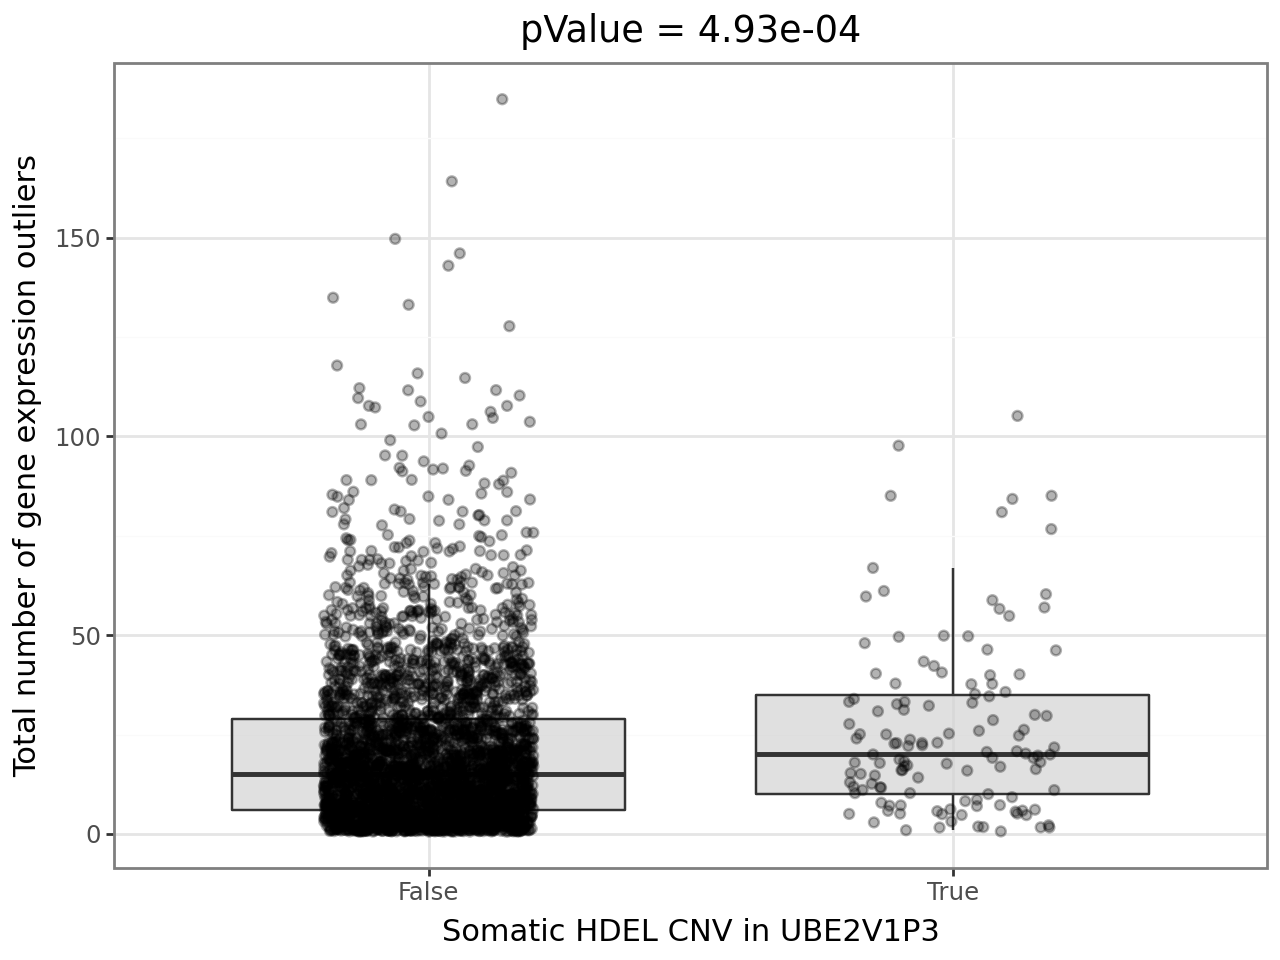

In [ ]:
for p in plots:
    p.show()

In [17]:
min_pval

np.float64(0.0005896435106471841)